In [1]:
# ==========================================
# MILESTONE 3 - MODELING & ADVANCED ANALYSIS
# Netflix Content Strategy Analyzer
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


In [6]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("netflix_cleaned.csv")

print(df.head())
print(df.info())

  show_id     type                          title             director  \
0      s8    Movie                        Sankofa         Haile Gerima   
1      s9  TV Show  The Great British Baking Show      Andy Devonshire   
2     s10    Movie                   The Starling       Theodore Melfi   
3     s13    Movie                   Je Suis Karl  Christian Schwochow   
4     s25    Movie                          Jeans           S. Shankar   

                                                cast  \
0  Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
1  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...   
2  Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   
3  Luna Wedler, Jannis Niewöhner, Milan Peschel, ...   
4  Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...   

                                             country          date_added  \
0  United States, Ghana, Burkina Faso, United Kin...  September 24, 2021   
1                                     United Kingdom  September 24

In [7]:
# ==========================================
# Data Preparation
# ==========================================

# Convert duration to numeric
df["duration_num"] = df["duration"].astype(str).str.extract(r'(\d+)')
df["duration_num"] = pd.to_numeric(df["duration_num"], errors="coerce")
df["duration_num"] = df["duration_num"].fillna(df["duration_num"].median())

# Select important columns
features = [
    "release_year",
    "duration_num",
    "rating",
    "country",
    "listed_in"
]

data = df[features].copy()

# Fill missing values
data["country"] = data["country"].fillna("Unknown")
data["rating"] = data["rating"].fillna("Unknown")
data["listed_in"] = data["listed_in"].fillna("Unknown")

# One-Hot Encoding
data = pd.get_dummies(data)

# Fill numeric missing values
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("Data Prepared Successfully!")

Data Prepared Successfully!


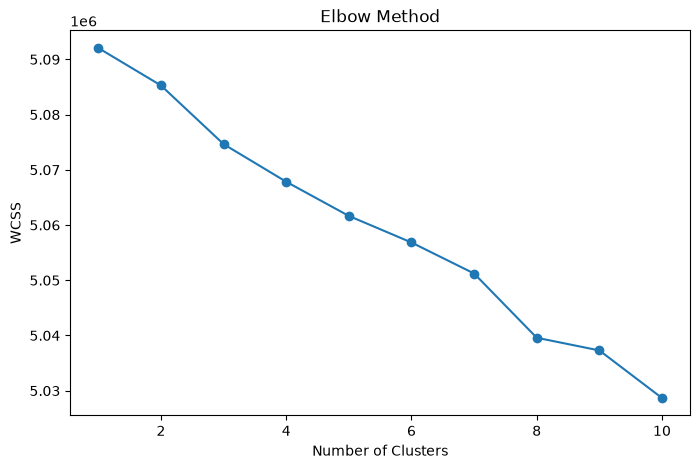

In [8]:
# ==========================================
# K-Means Clustering - Elbow Method
# ==========================================

wcss = []

for i in range(1, 11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_data)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.savefig("elbow_method.png")
plt.show()

In [9]:
# ==========================================
# Apply K-Means Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

print(df[["title", "Cluster"]].head())

                           title  Cluster
0                        Sankofa        2
1  The Great British Baking Show        2
2                   The Starling        2
3                   Je Suis Karl        2
4                          Jeans        1


In [10]:
# ==========================================
# Cluster Summary
# ==========================================

print("\n===== Cluster Summary =====")

for cluster in sorted(df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    cluster_data = df[df["Cluster"] == cluster]

    print("\nContent Type:")
    print(cluster_data["type"].value_counts())

    print("\nTop Countries:")
    print(cluster_data["country"].value_counts().head())

    print("\nTop Genres:")
    print(cluster_data["listed_in"].value_counts().head())

    print("-"*50)


===== Cluster Summary =====

Cluster 0

Content Type:
type
Movie      12
TV Show     7
Name: count, dtype: int64

Top Countries:
country
Taiwan    19
Name: count, dtype: int64

Top Genres:
listed_in
Horror Movies, International Movies                       2
Dramas, International Movies                              2
Crime TV Shows, International TV Shows, TV Dramas         2
International TV Shows, Romantic TV Shows, TV Comedies    1
Comedies, Dramas, Independent Movies                      1
Name: count, dtype: int64
--------------------------------------------------

Cluster 1

Content Type:
type
Movie      1586
TV Show       2
Name: count, dtype: int64

Top Countries:
country
India        854
Egypt         89
Nigeria       83
Indonesia     75
Turkey        75
Name: count, dtype: int64

Top Genres:
listed_in
Dramas, International Movies                        214
Comedies, Dramas, International Movies              207
Dramas, International Movies, Romantic Movies       140
Dramas, 

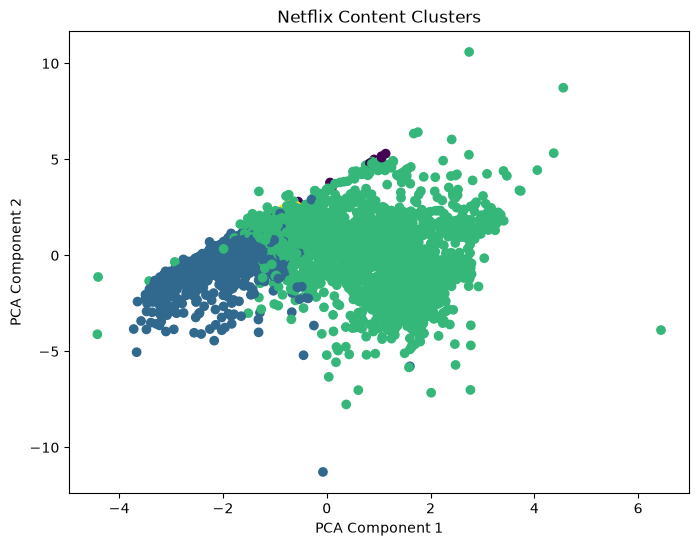

In [11]:
# ==========================================
# PCA Visualization
# ==========================================

pca = PCA(n_components=2)

components = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Netflix Content Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.savefig("clusters_pca.png")
plt.show()

In [13]:
# ==========================================
# Classification
# Predict Movie vs TV Show
# ==========================================

target = df["type"]

X = data
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
# ==========================================
# Train Random Forest
# ==========================================

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

In [15]:
# ==========================================
# Model Evaluation
# ==========================================

print("Accuracy")
print(accuracy_score(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, pred)

print(cm)

Accuracy
0.9990627928772259

Classification Report
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1035
     TV Show       0.97      1.00      0.98        32

    accuracy                           1.00      1067
   macro avg       0.98      1.00      0.99      1067
weighted avg       1.00      1.00      1.00      1067


Confusion Matrix
[[1034    1]
 [   0   32]]


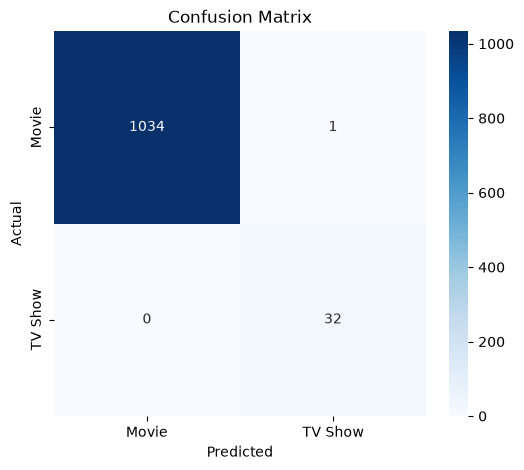

In [16]:
# ==========================================
# Confusion Matrix Visualization
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

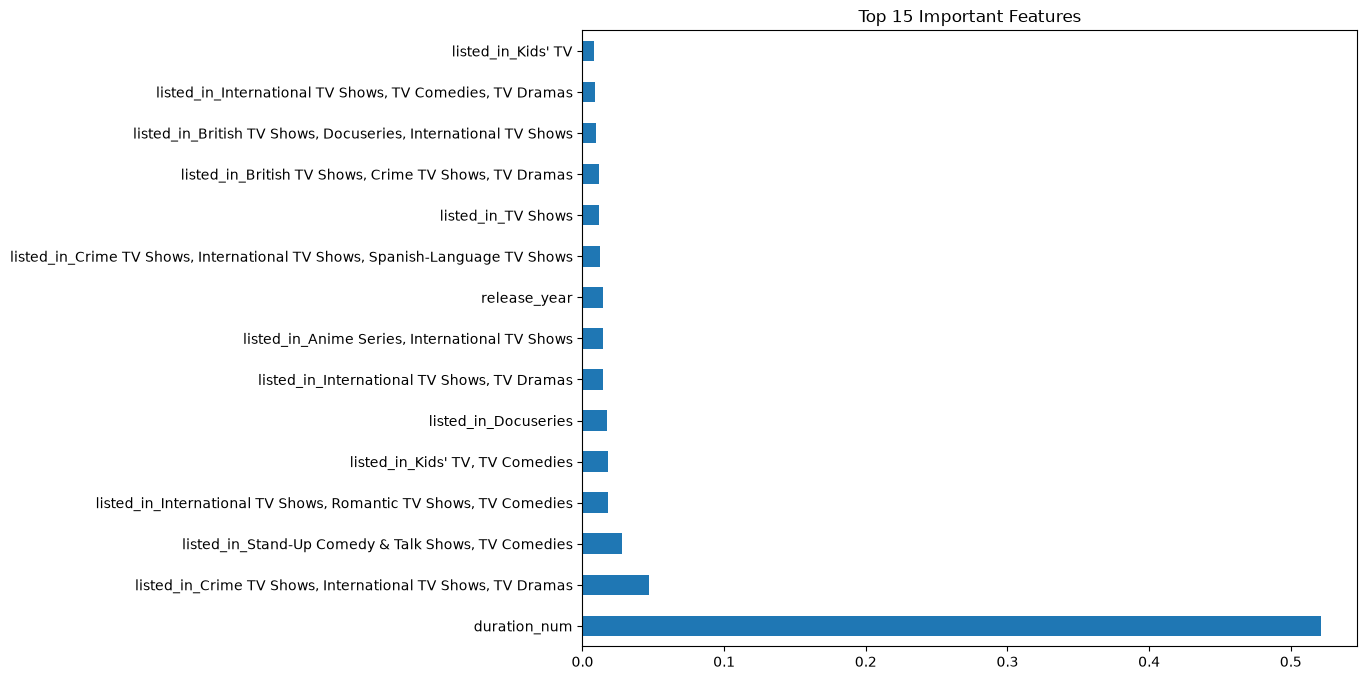


Top Important Features
duration_num                                                                   0.521020
listed_in_Crime TV Shows, International TV Shows, TV Dramas                    0.046719
listed_in_Stand-Up Comedy & Talk Shows, TV Comedies                            0.027776
listed_in_International TV Shows, Romantic TV Shows, TV Comedies               0.018228
listed_in_Kids' TV, TV Comedies                                                0.018102
listed_in_Docuseries                                                           0.017344
listed_in_International TV Shows, TV Dramas                                    0.014776
listed_in_Anime Series, International TV Shows                                 0.014487
release_year                                                                   0.014477
listed_in_Crime TV Shows, International TV Shows, Spanish-Language TV Shows    0.012573
listed_in_TV Shows                                                             0.011653
listed_i

In [17]:
# ==========================================
# Feature Importance
# ==========================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.savefig("feature_importance.png")

plt.show()

print("\nTop Important Features")

print(importance.head(15))

In [18]:
# ==========================================
# Save Final Dataset
# ==========================================

df.to_csv(
    "netflix_milestone3_output.csv",
    index=False
)

print("Milestone 3 Completed Successfully!")

Milestone 3 Completed Successfully!
